# Churn Prediction
* One of the powerful tools to improve Retention Rate (hence the PMF(product market fit)) is Churn Prediction. By using this technique, we can easily find out who is likely to churn in the given period.

### Import libraries

In [ ]:
from __future__ import division
from datetime import datetime, timedelta,date

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
%matplotlib inline

import seaborn as sns

import plotly.offline as pyoff
import plotly.graph_objs as go

import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.cluster import KMeans

In [2]:
df_data = pd.read_csv('../datasets/churn_data.csv')
df_data.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Exploratory Data Analysis 

In [4]:
df_data.loc[df_data.Churn=='No','Churn'] = 0 
df_data.loc[df_data.Churn=='Yes','Churn'] = 1

### Categorical attribute visualization

In [5]:
def visualization_churn_rate(category):
    df_plot = df_data.groupby(category).Churn.mean().reset_index()
    plot_data = [
        go.Bar(
            x=df_plot[category],
            y=df_plot['Churn'],
            width = [0.5, 0.5],
            marker=dict(
            color=['green', 'blue','yellow'])
        )
    ]
    plot_layout = go.Layout(
            xaxis={"type": "category"},
            yaxis={"title": "Churn Rate"},
            title=category,
            plot_bgcolor  = 'rgb(243,243,243)',
            paper_bgcolor  = 'rgb(243,243,243)',
        )
    fig = go.Figure(data=plot_data, layout=plot_layout)
    fig.show()

In [6]:
visualization_churn_rate('gender')

In [7]:
df_data.groupby('gender').Churn.mean()
#Female customers are more likely to churn vs. male customers, but the difference is minimal (~0.8%).

gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: object

In [8]:
visualization_churn_rate('InternetService')

In [9]:
visualization_churn_rate('Contract')

In [10]:
visualization_churn_rate('TechSupport')

In [11]:
visualization_churn_rate('PaymentMethod')

In [12]:
visualization_churn_rate('PaperlessBilling')

In [13]:
visualization_churn_rate('StreamingMovies')

In [14]:
visualization_churn_rate('DeviceProtection')

In [15]:
visualization_churn_rate('PhoneService')

### Numeric attribute visualization

In [16]:
def numeric_visualization_churn_rate(category):
    df_plot = df_data.groupby(category).Churn.mean().reset_index()
    plot_data = [
        go.Scatter(
            x=df_plot[category],
            y=df_plot['Churn'],
            mode='markers',
            name='Low',
            marker= dict(size= 7,
                line= dict(width=1),
                color= 'blue',
                opacity= 0.8
               ),
        )
    ]
    plot_layout = go.Layout(
            yaxis= {'title': "Churn Rate"},
            xaxis= {'title': category},
            title=category,
            plot_bgcolor  = "rgb(243,243,243)",
            paper_bgcolor  = "rgb(243,243,243)",
        )
    fig = go.Figure(data=plot_data, layout=plot_layout)
    fig.show()

In [17]:
numeric_visualization_churn_rate('tenure')

In [18]:
numeric_visualization_churn_rate('MonthlyCharges')

In [19]:
numeric_visualization_churn_rate('TotalCharges')

## Feature Engineering

In [20]:
# from sklearn.cluster import KMeans

# sse={}
# df_tenure = df_data[['tenure']]

# for k in range(1, 10):
#     kmeans = KMeans(n_clusters=k, max_iter=1000).fit(df_tenure)
#     df_tenure["clusters"] = kmeans.labels_
#     sse[k] = kmeans.inertia_ 
# plt.figure()
# plt.plot(list(sse.keys()), list(sse.values()))
# plt.xlabel("Number of cluster")
# plt.show()

In [21]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(df_data[['tenure']])
df_data['TenureCluster'] = kmeans.predict(df_data[['tenure']])

In [22]:
df_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureCluster
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,2
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,0,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,2
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2


In [23]:
df_data.groupby('TenureCluster').tenure.describe()

,count,mean,std,min,25%,50%,75%,max
TenureCluster,,,,,,,,
0,1862.0,33.367884,7.910875,21.0,26.0,33.0,40.0,47.0
1,2303.0,62.630482,7.777547,48.0,56.0,64.0,70.0,72.0
2,2878.0,7.512509,5.977337,0.0,2.0,6.0,12.0,20.0


In [24]:
df_data.loc[df_data.TenureCluster==0,'TenureCluster'] = 'Mid'
df_data.loc[df_data.TenureCluster==1,'TenureCluster'] = 'High'
df_data.loc[df_data.TenureCluster==2,'TenureCluster'] = 'Low'

/var/folders/xh/pw8bqmds2zv_n5f5qwk66jvr0000gn/T/ipykernel_85207/285311232.py:1: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Mid' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.



In [25]:
visualization_churn_rate('TenureCluster')

In [26]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(df_data[['MonthlyCharges']])
df_data['MonthlyChargesCluster'] = kmeans.predict(df_data[['MonthlyCharges']])

In [27]:
df_data.groupby('MonthlyChargesCluster').MonthlyCharges.describe()

,count,mean,std,min,25%,50%,75%,max
MonthlyChargesCluster,,,,,,,,
0,2241.0,61.643284,10.448008,42.60,51.8,61.55,70.7000,77.85
1,1892.0,23.384619,5.660437,18.25,19.8,20.40,25.0500,42.40
2,2910.0,94.065395,10.338766,77.90,85.1,93.90,101.9375,118.75


In [28]:
df_data.loc[df_data.MonthlyChargesCluster==0,'MonthlyChargesCluster'] = 'High'
df_data.loc[df_data.MonthlyChargesCluster==1,'MonthlyChargesCluster'] = 'Mid'
df_data.loc[df_data.MonthlyChargesCluster==2,'MonthlyChargesCluster'] = 'Low'

visualization_churn_rate('MonthlyChargesCluster')

/var/folders/xh/pw8bqmds2zv_n5f5qwk66jvr0000gn/T/ipykernel_85207/1421199296.py:1: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'High' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.



In [29]:
#import Label Encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
dummy_columns = [] #array for multiple value columns
for column in df_data.columns:
    if df_data[column].dtype == object and column != 'customerID':
        if df_data[column].nunique() == 2:
            #apply Label Encoder for binary ones
            df_data[column] = le.fit_transform(df_data[column]) 
        else:
            dummy_columns.append(column)
#apply get dummies for selected columns
df_data = pd.get_dummies(data = df_data,columns = dummy_columns)

In [30]:
df_data[['gender','TenureCluster_High','TenureCluster_Mid','TenureCluster_Low']].head()

,gender,TenureCluster_High,TenureCluster_Mid,TenureCluster_Low
0,0,False,False,True
1,1,False,True,False
2,1,False,False,True
3,1,False,True,False
4,0,False,False,True


## Binary Classification Model with XGBoost

In [31]:
#create feature set and labels
X = df_data.drop(['Churn','customerID'],axis=1)
y = df_data.Churn
#train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=56)
#building the model & printing the score
xgb_model = xgb.XGBClassifier(max_depth=5, learning_rate=0.08, objective= 'binary:logistic',n_jobs=-1).fit(X_train, y_train)
print('Accuracy of XGB classifier on training set: {:.2f}'
       .format(xgb_model.score(X_train, y_train)))
print('Accuracy of XGB classifier on test set: {:.2f}'
       .format(xgb_model.score(X_test[X_train.columns], y_test)))

Accuracy of XGB classifier on training set: 0.83
Accuracy of XGB classifier on test set: 0.83


In [32]:
y_pred = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.90      0.89       267
           1       0.66      0.62      0.64        86

    accuracy                           0.83       353
   macro avg       0.77      0.76      0.76       353
weighted avg       0.83      0.83      0.83       353



### ROC Curve Analysis
Evaluating model performance across all classification thresholds

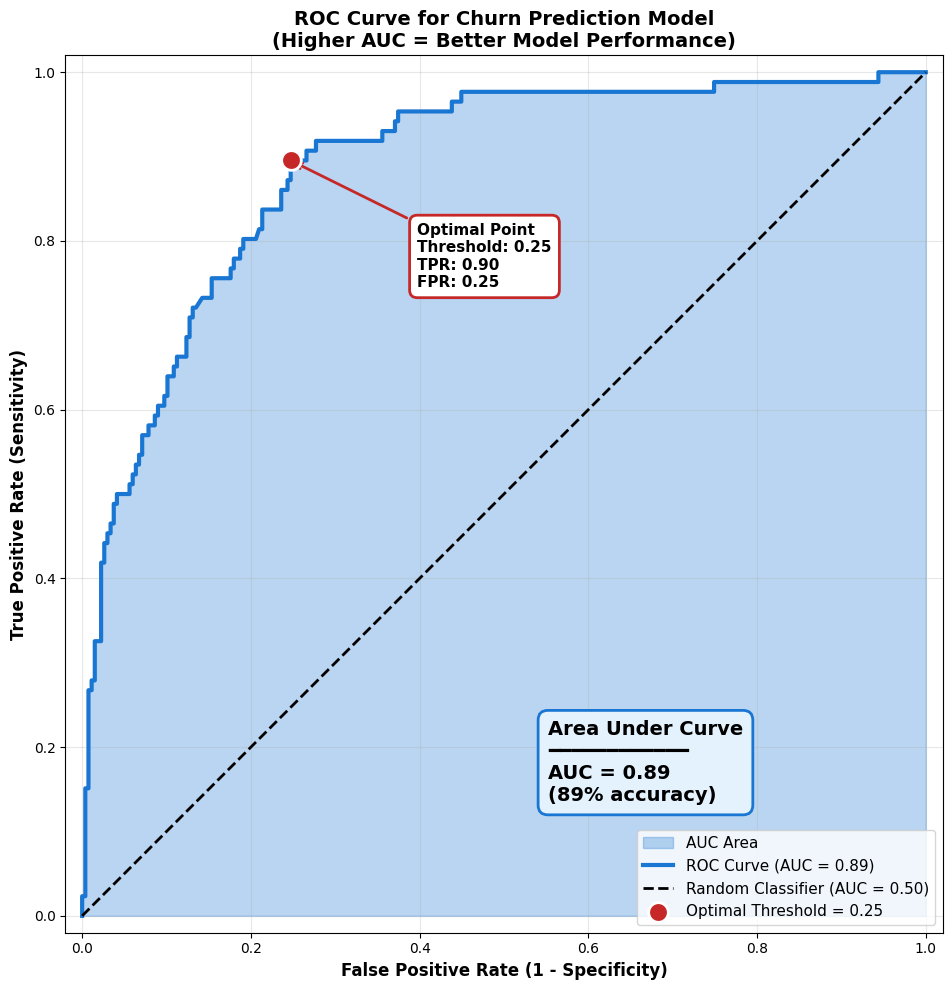


📊 ROC Curve Interpretation:
• AUC = 0.89 - Good classifier performance
• Optimal threshold: 0.25
• At optimal threshold: TPR = 0.90, FPR = 0.25


In [33]:
# ROC Curve with AUC
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get prediction probabilities
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Find optimal threshold (Youden's J statistic)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 10))

# Fill area under ROC curve
ax.fill_between(fpr, tpr, alpha=0.3, color='#1976D2', label='AUC Area')

# Plot ROC curve
ax.plot(fpr, tpr, color='#1976D2', linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.2f})')

# Plot diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.50)')

# Mark optimal threshold point
ax.scatter([optimal_fpr], [optimal_tpr], s=200, c='#C62828', zorder=5, 
           edgecolors='white', linewidth=2, label=f'Optimal Threshold = {optimal_threshold:.2f}')

# Add annotation for optimal point
ax.annotate(f'Optimal Point\nThreshold: {optimal_threshold:.2f}\nTPR: {optimal_tpr:.2f}\nFPR: {optimal_fpr:.2f}',
            xy=(optimal_fpr, optimal_tpr),
            xytext=(optimal_fpr + 0.15, optimal_tpr - 0.15),
            fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#C62828', linewidth=2),
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=2))

# Add AUC annotation box
ax.annotate(f'Area Under Curve\n━━━━━━━━━━━━\nAUC = {roc_auc:.2f}\n({roc_auc*100:.0f}% accuracy)',
            xy=(0.55, 0.15),
            xycoords='axes fraction',
            fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#E3F2FD', edgecolor='#1976D2', linewidth=2))

# Styling
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve for Churn Prediction Model\n(Higher AUC = Better Model Performance)', 
             fontsize=14, fontweight='bold')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('roc_curve_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 ROC Curve Interpretation:")
print(f"• AUC = {roc_auc:.2f} - {'Excellent' if roc_auc > 0.9 else 'Good' if roc_auc > 0.8 else 'Fair' if roc_auc > 0.7 else 'Poor'} classifier performance")
print(f"• Optimal threshold: {optimal_threshold:.2f}")
print(f"• At optimal threshold: TPR = {optimal_tpr:.2f}, FPR = {optimal_fpr:.2f}")

### Feature Importance Analysis
Understanding which features drive churn predictions

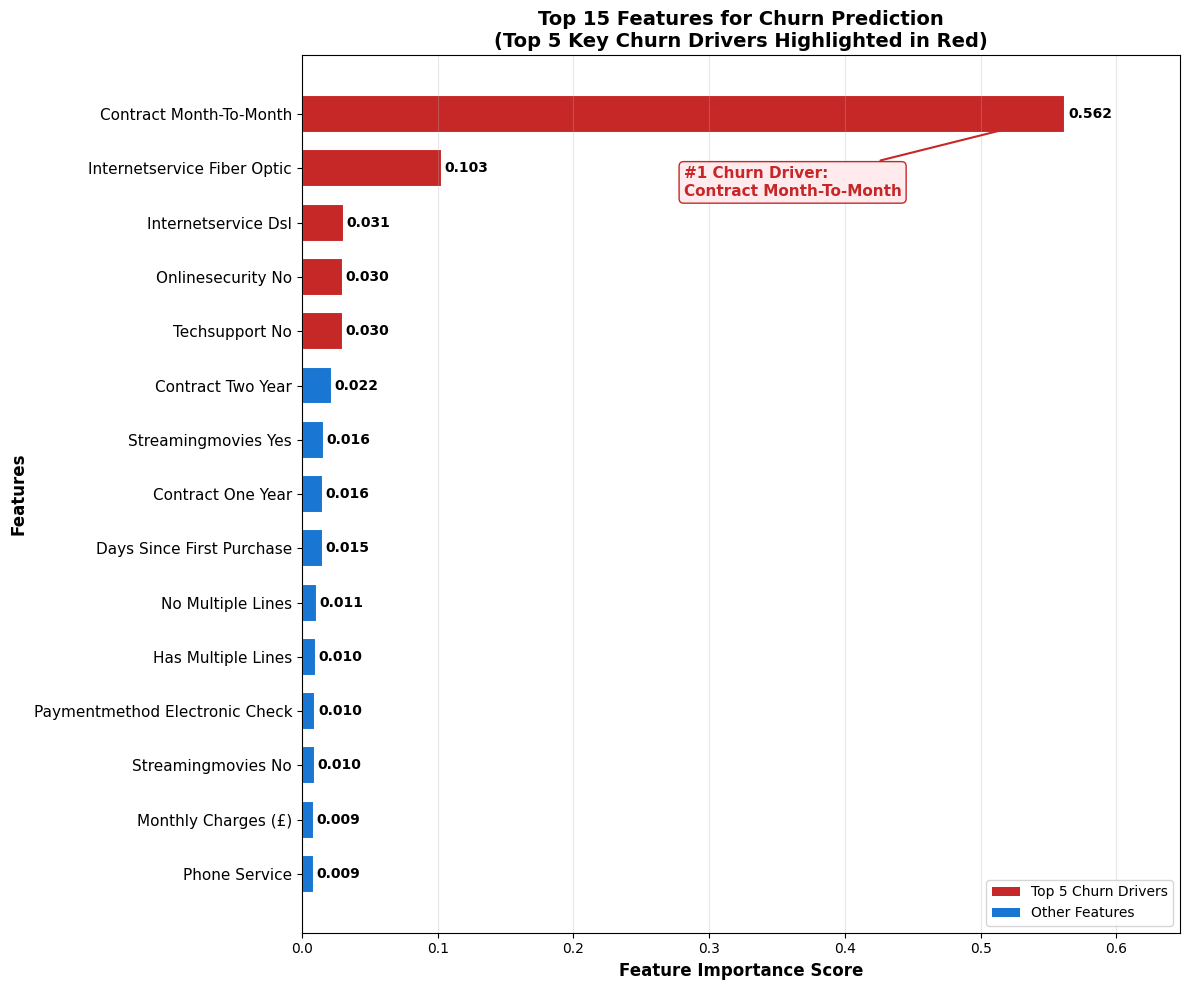


📊 Top 5 Churn Drivers:
  1. Contract Month-To-Month: 0.562
  2. Internetservice Fiber Optic: 0.103
  3. Internetservice Dsl: 0.031
  4. Onlinesecurity No: 0.030
  5. Techsupport No: 0.030


In [34]:
# Feature Importance Horizontal Bar Chart
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Map feature names to more readable labels
feature_labels = {
    'tenure': 'Days Since First Purchase',
    'MonthlyCharges': 'Monthly Charges (£)',
    'TotalCharges': 'Total Charges (£)',
    'SeniorCitizen': 'Senior Citizen Flag',
    'gender': 'Gender',
    'Partner': 'Has Partner',
    'Dependents': 'Has Dependents',
    'PhoneService': 'Phone Service',
    'MultipleLines_No': 'No Multiple Lines',
    'MultipleLines_Yes': 'Has Multiple Lines',
    'OnlineSecurity': 'Online Security',
    'OnlineBackup': 'Online Backup',
    'DeviceProtection': 'Device Protection',
    'TechSupport': 'Tech Support',
    'StreamingTV': 'Streaming TV',
    'StreamingMovies': 'Streaming Movies',
    'PaperlessBilling': 'Paperless Billing',
    'TenureCluster_High': 'High Tenure Cluster',
    'TenureCluster_Mid': 'Mid Tenure Cluster',
    'TenureCluster_Low': 'Low Tenure Cluster',
    'MonthlyChargesCluster_High': 'High Monthly Charges',
    'MonthlyChargesCluster_Mid': 'Mid Monthly Charges',
    'MonthlyChargesCluster_Low': 'Low Monthly Charges'
}

# Apply labels (use original name if not in mapping)
feature_importance['FeatureLabel'] = feature_importance['Feature'].apply(
    lambda x: feature_labels.get(x, x.replace('_', ' ').title())
)

# Take top 15 features
top_features = feature_importance.tail(15)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 10))

# Define colors - top 5 features in red (churn indicators), rest in blue
n_features = len(top_features)
colors = ['#1976D2'] * n_features  # Default blue
for i in range(min(5, n_features)):
    colors[n_features - 1 - i] = '#C62828'  # Top 5 in red

# Create horizontal bar chart
bars = ax.barh(range(n_features), top_features['Importance'], 
               color=colors, edgecolor='white', linewidth=1.5, height=0.7)

# Add value labels on bars
for i, (bar, importance) in enumerate(zip(bars, top_features['Importance'])):
    width = bar.get_width()
    ax.text(width + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{importance:.3f}', va='center', fontsize=10, fontweight='bold')

# Customize y-axis labels
ax.set_yticks(range(n_features))
ax.set_yticklabels(top_features['FeatureLabel'], fontsize=11)

# Add styling
ax.set_xlabel('Feature Importance Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Features for Churn Prediction\n(Top 5 Key Churn Drivers Highlighted in Red)', 
             fontsize=14, fontweight='bold')
ax.set_xlim(0, top_features['Importance'].max() * 1.15)
ax.grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C62828', label='Top 5 Churn Drivers'),
                   Patch(facecolor='#1976D2', label='Other Features')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

# Add insight annotation for top feature
top_feature = top_features.iloc[-1]
ax.annotate(f'#1 Churn Driver:\n{top_feature["FeatureLabel"]}',
            xy=(top_feature['Importance'], n_features - 1),
            xytext=(top_feature['Importance'] * 0.5, n_features - 2.5),
            fontsize=11, fontweight='bold', color='#C62828',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor='#C62828'),
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.5))

plt.tight_layout()
plt.savefig('feature_importance_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 5 features summary
print("\n📊 Top 5 Churn Drivers:")
for i, (_, row) in enumerate(top_features.tail(5).iloc[::-1].iterrows()):
    print(f"  {i+1}. {row['FeatureLabel']}: {row['Importance']:.3f}")

### Churn Probability Distribution
Understanding the risk profile of your customer base

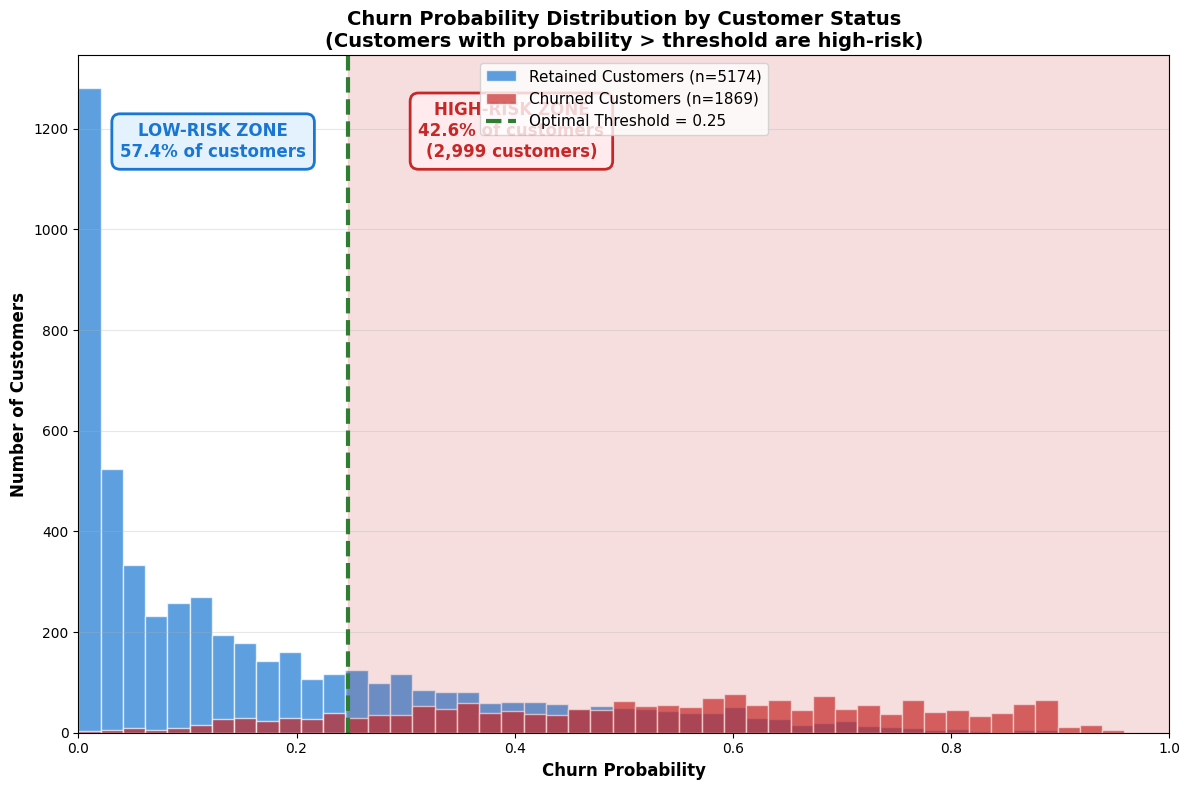


📊 Churn Risk Distribution:
• Total customers: 7,043
• High-risk customers (prob > 0.25): 2,999 (42.6%)
• Low-risk customers: 4,044 (57.4%)
• Actual churn rate: 26.5%


In [35]:
# Churn Probability Distribution - Two-color histogram
# Get probabilities for all customers
all_probs = xgb_model.predict_proba(df_data[X_train.columns])[:, 1]
df_data['churn_probability'] = all_probs

# Separate by actual churn status
churned_probs = df_data[df_data['Churn'] == 1]['churn_probability']
retained_probs = df_data[df_data['Churn'] == 0]['churn_probability']

# Calculate high-risk customers (above threshold)
high_risk_count = (all_probs >= optimal_threshold).sum()
high_risk_pct = high_risk_count / len(all_probs) * 100

fig, ax = plt.subplots(figsize=(12, 8))

# Create overlapping histograms
bins = np.linspace(0, 1, 50)
ax.hist(retained_probs, bins=bins, alpha=0.7, color='#1976D2', 
        label=f'Retained Customers (n={len(retained_probs)})', edgecolor='white')
ax.hist(churned_probs, bins=bins, alpha=0.7, color='#C62828', 
        label=f'Churned Customers (n={len(churned_probs)})', edgecolor='white')

# Add optimal threshold line
ax.axvline(x=optimal_threshold, color='#2E7D32', linewidth=3, linestyle='--', 
           label=f'Optimal Threshold = {optimal_threshold:.2f}')

# Shade high-risk zone
ax.axvspan(optimal_threshold, 1, alpha=0.15, color='#C62828')

# Add annotation for high-risk zone
ax.annotate(f'HIGH-RISK ZONE\n{high_risk_pct:.1f}% of customers\n({high_risk_count:,} customers)',
            xy=(optimal_threshold + 0.15, ax.get_ylim()[1] * 0.85),
            fontsize=12, fontweight='bold', color='#C62828',
            ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFEBEE', edgecolor='#C62828', linewidth=2))

# Add annotation for low-risk zone
low_risk_pct = 100 - high_risk_pct
ax.annotate(f'LOW-RISK ZONE\n{low_risk_pct:.1f}% of customers',
            xy=(optimal_threshold / 2, ax.get_ylim()[1] * 0.85),
            fontsize=12, fontweight='bold', color='#1976D2',
            ha='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#E3F2FD', edgecolor='#1976D2', linewidth=2))

# Styling
ax.set_xlabel('Churn Probability', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Customers', fontsize=12, fontweight='bold')
ax.set_title('Churn Probability Distribution by Customer Status\n(Customers with probability > threshold are high-risk)', 
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.legend(loc='upper center', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('churn_probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Churn Risk Distribution:")
print(f"• Total customers: {len(all_probs):,}")
print(f"• High-risk customers (prob > {optimal_threshold:.2f}): {high_risk_count:,} ({high_risk_pct:.1f}%)")
print(f"• Low-risk customers: {len(all_probs) - high_risk_count:,} ({low_risk_pct:.1f}%)")
print(f"• Actual churn rate: {df_data['Churn'].mean()*100:.1f}%")

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

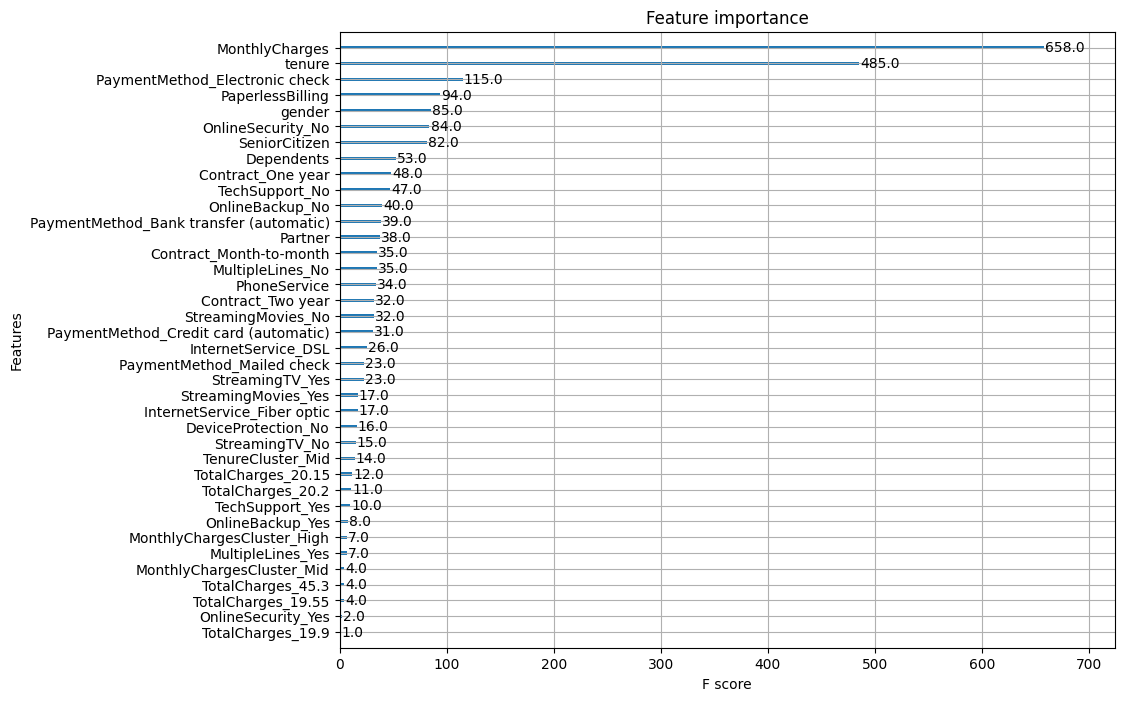

In [36]:
from xgboost import plot_importance
fig, ax = plt.subplots(figsize=(10,8))
plot_importance(xgb_model, ax=ax)

In [37]:
df_data['probablity'] = xgb_model.predict_proba(df_data[X_train.columns])[:,1]

In [38]:
df_data[['customerID','probablity']].head()

,customerID,probablity
0,7590-VHVEG,0.648757
1,5575-GNVDE,0.037824
2,3668-QPYBK,0.315613
3,7795-CFOCW,0.038562
4,9237-HQITU,0.628329


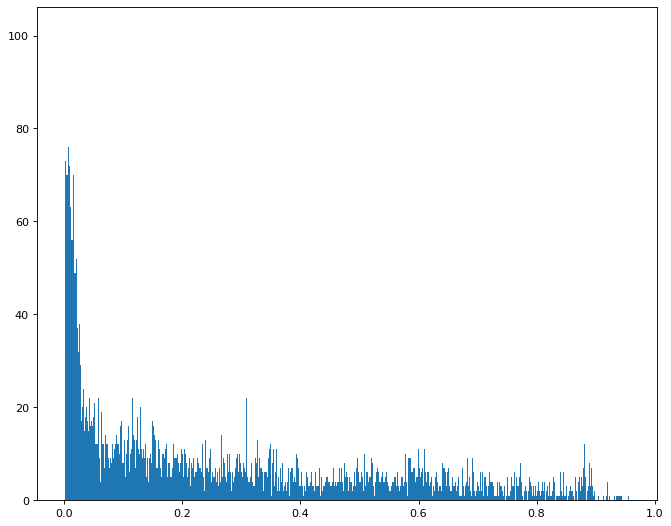

In [39]:
figure(num=None, figsize=(10, 8), dpi=80, facecolor='w', edgecolor='k')
plt.hist(x=df_data['probablity'], bins=1000)
plt.show()